In [ ]:
!pip install -qU av==17.0.1 transformers==5.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 63.2 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import Sam2VideoModel, Sam2VideoProcessor
from transformers.video_utils import load_video

In [ ]:
file_id = "1g2a2-HLEuwWFMsoDD1iqTx2NBuiCDSDD"
!gdown $file_id --output movie_players.mp4

Downloading...
From: https://drive.google.com/uc?id=1g2a2-HLEuwWFMsoDD1iqTx2NBuiCDSDD
To: /content/movie_players.mp4
100% 2.43M/2.43M [00:00<00:00, 8.21MB/s]


In [ ]:
video_frames, _ = load_video("movie_players.mp4")

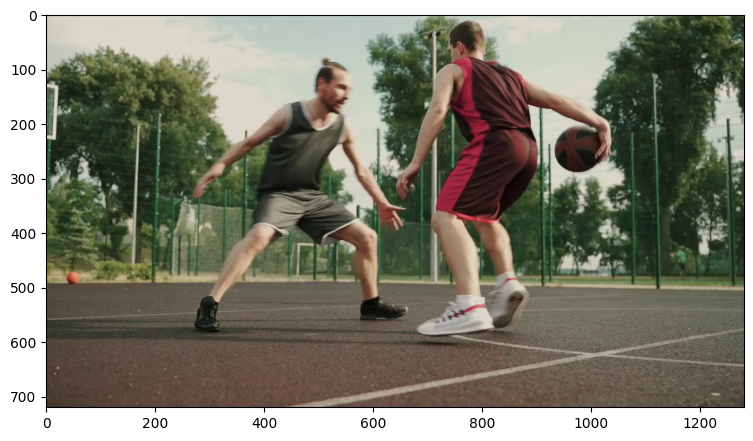

In [ ]:
plt.figure(figsize=(9, 6))
plt.imshow(video_frames[0])
plt.show()

In [ ]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

In [ ]:
model = Sam2VideoModel.from_pretrained("facebook/sam2.1-hiera-tiny", device_map="auto")
processor = Sam2VideoProcessor.from_pretrained("facebook/sam2.1-hiera-tiny")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:85: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


Loading weights:   0%|          | 0/469 [00:00<?, ?it/s]

In [ ]:
# Add click on first frame to select object
ann_frame_idx = 0
ann_obj_id = 1
points = [[[[995, 239]]]]
labels = [[[1]]]

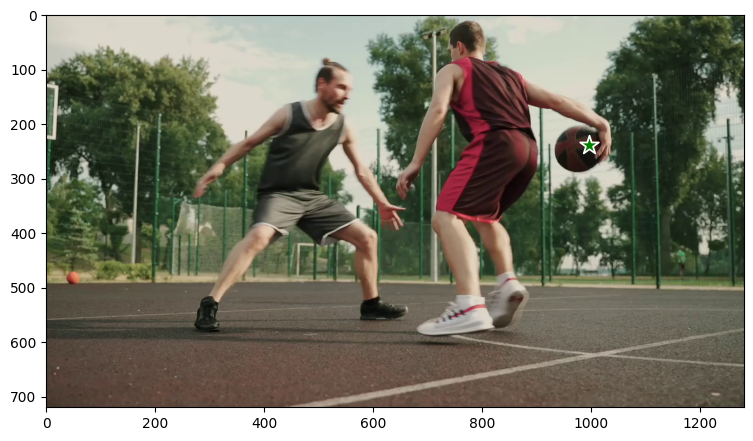

In [ ]:
plt.figure(figsize=(9, 6))
plt.imshow(video_frames[0])
show_points(np.array(points[0]), np.array(labels[0]), plt.gca())

In [ ]:
# Initialize video inference session
device = "cuda" if torch.cuda.is_available() else "cpu"
inference_session = processor.init_video_session(
    video=video_frames,
    inference_device=device,
)

processor.add_inputs_to_inference_session(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=ann_obj_id,
    input_points=points,
    input_labels=labels,
)

# Segment the object on the first frame
outputs = model(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
)
video_res_masks = processor.post_process_masks(
    masks=[outputs.pred_masks],
    original_sizes=[[inference_session.video_height, inference_session.video_width]],
    binarize=True
)[0]
print(f"Segmentation shape: {video_res_masks.shape}")

Segmentation shape: torch.Size([1, 1, 720, 1280])


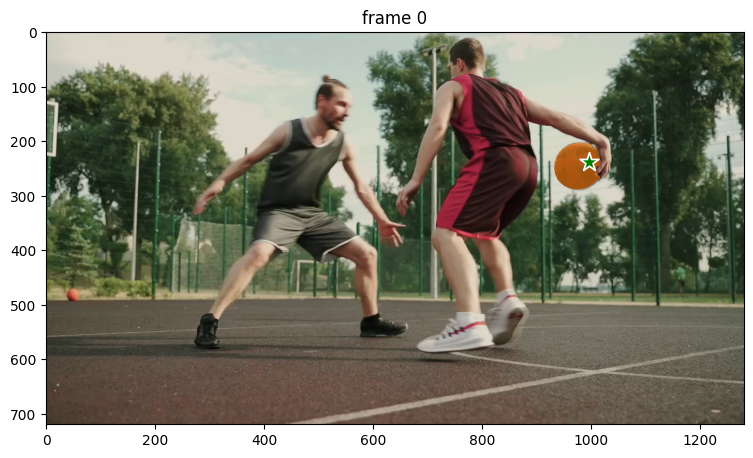

In [ ]:
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(video_frames[ann_frame_idx])
show_points(np.array(points[0]), np.array(labels[0]), plt.gca())
show_mask(video_res_masks[0].squeeze().cpu().numpy(), plt.gca(), obj_id=ann_obj_id)

In [ ]:
# Propagate through the entire video
video_segments = {}
for sam2_video_output in model.propagate_in_video_iterator(inference_session):
    video_res_masks = processor.post_process_masks(
        masks=[sam2_video_output.pred_masks],
        original_sizes=[[inference_session.video_height, inference_session.video_width]],
        binarize=True,
    )[0]
    video_segments[sam2_video_output.frame_idx] = video_res_masks

print(f"Tracked object through {len(video_segments)} frames")

Tracked object through 332 frames


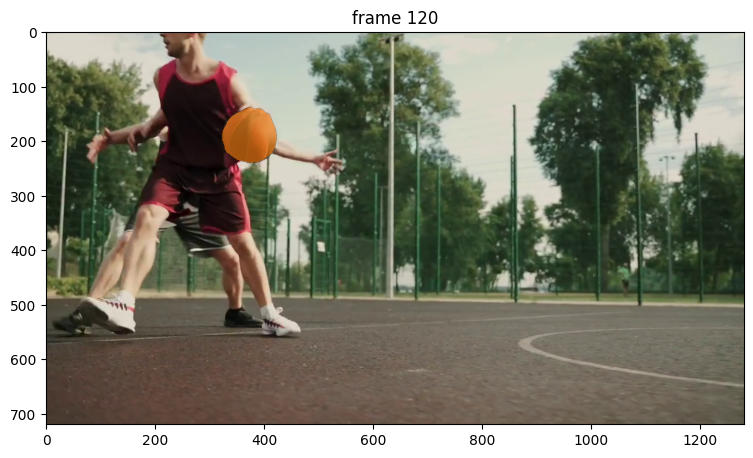

In [ ]:
frame_idx = 120
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(video_frames[frame_idx])
show_mask(video_segments[frame_idx][0].squeeze().cpu().numpy(), plt.gca(), obj_id=ann_obj_id)

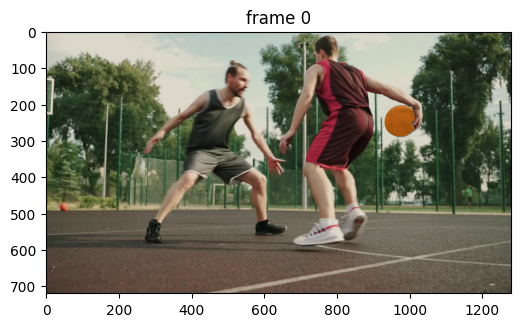

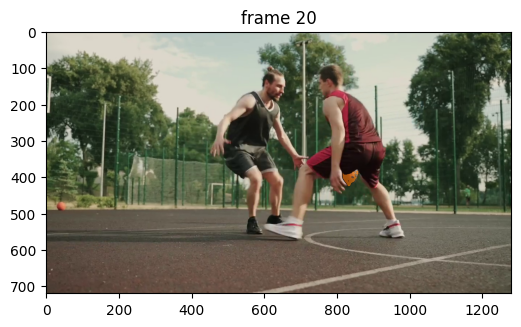

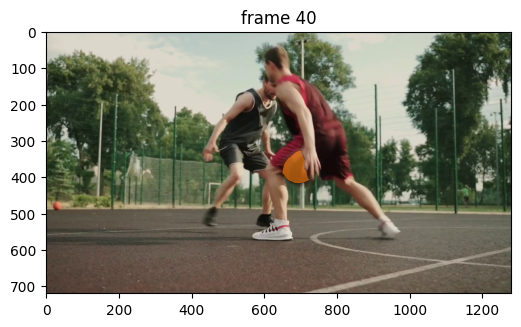

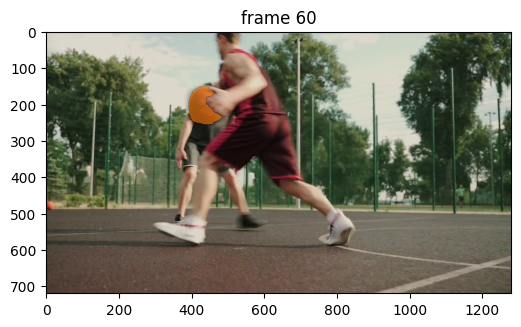

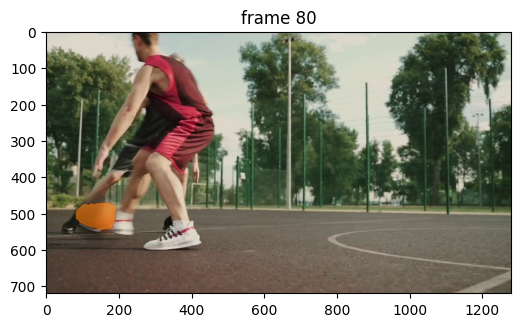

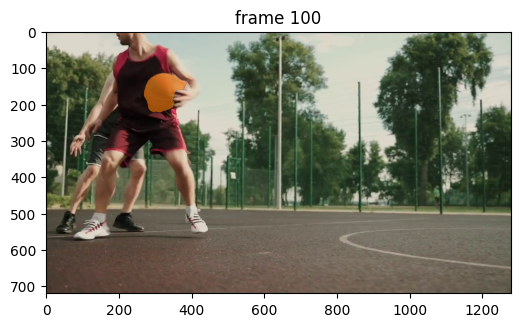

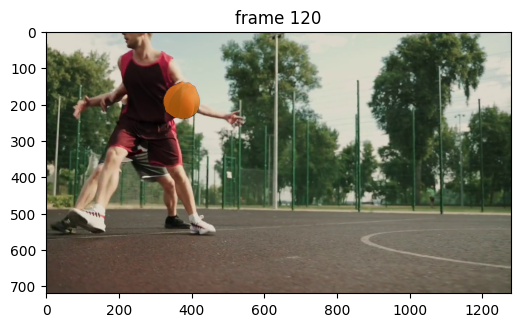

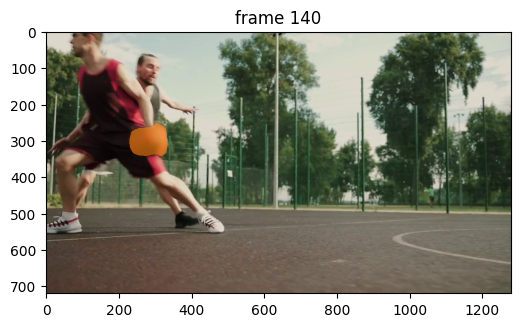

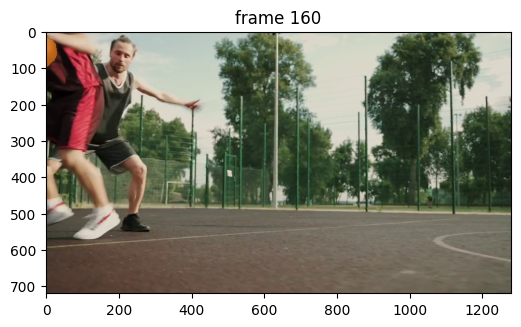

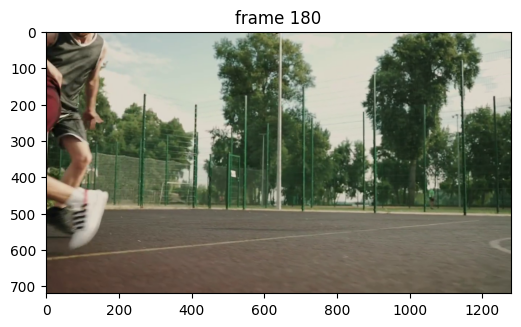

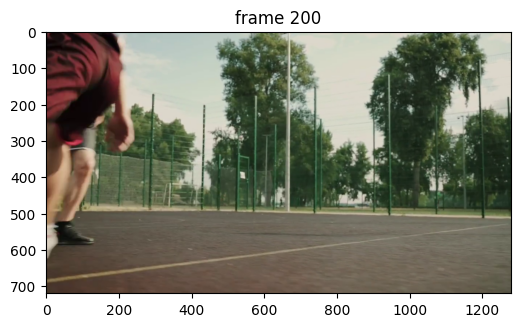

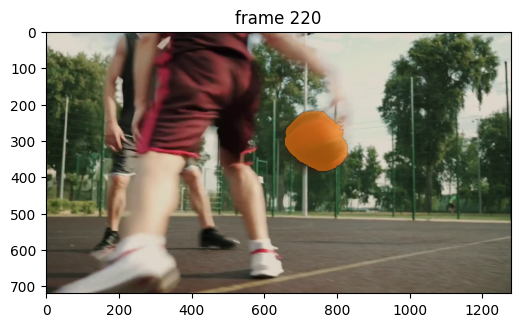

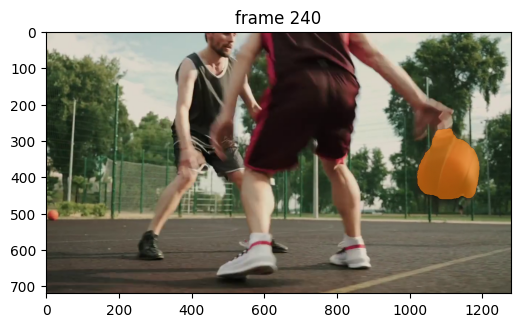

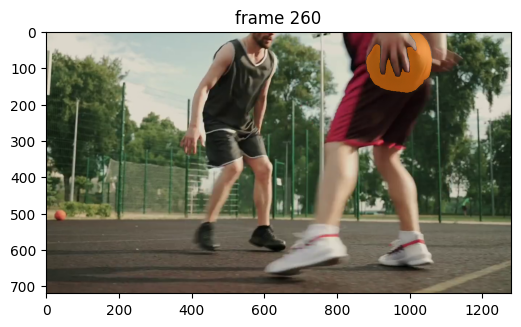

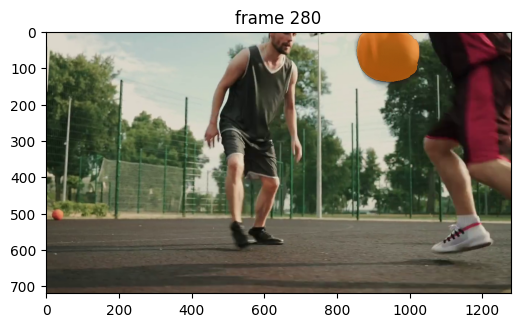

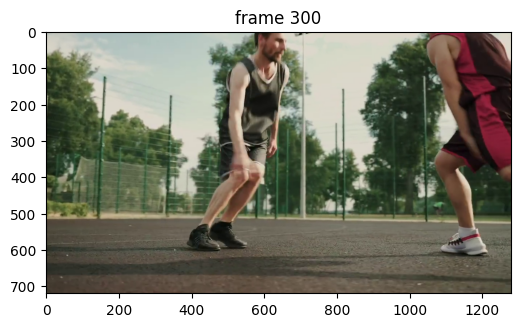

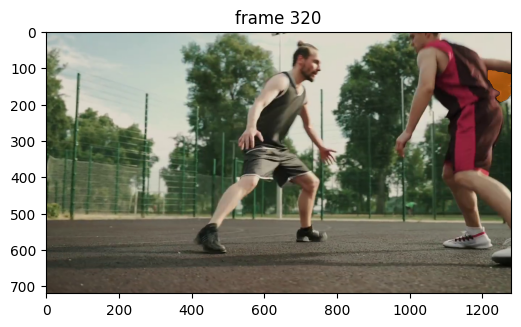

In [ ]:
# render the segmentation results every few frames
vis_frame_stride = 20
plt.close("all")
for out_frame_idx in range(0, len(video_frames), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(video_frames[out_frame_idx])
    for out_mask in video_segments[out_frame_idx]:
        show_mask(out_mask[0].squeeze().cpu().numpy(), plt.gca(), obj_id=ann_obj_id)